# Explainable AI — California Housing Regression

## Project: XGBoost + Four Complementary XAI Methods

**Goal:** Explain a non-trivial machine-learning model using complementary global, local, and actionable explainability methods.

**Model:** `XGBRegressor` (tree-based gradient boosting)
**Dataset:** California Housing (`scikit-learn`)
**Task:** Regression — predict `MedHouseVal`

### Explainability approaches
1. **Permutation Feature Importance** — global feature importance
2. **SHAP** — global and local explanations
3. **PDP + ICE** — marginal effects and instance-level heterogeneity
4. **Counterfactual Explanations (DiCE)** — actionable changes to model inputs


---
# 0) Environment & Reproducibility

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Model
from xgboost import XGBRegressor

# XAI
import shap

# Counterfactuals
import dice_ml

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("Environment initialized.")

c:\Users\milad\miniconda3\envs\xai-housing\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment initialized.


---
# 1) Data Loading & Initial Exploration

We use the California Housing dataset from scikit-learn. The target is `MedHouseVal`.

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

# Separate features and target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print("Shape X:", X.shape)
print("Target y shape:", y.shape)
display(df.head())

print("\nSummary:")
display(df.describe())

Shape X: (20640, 8)
Target y shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


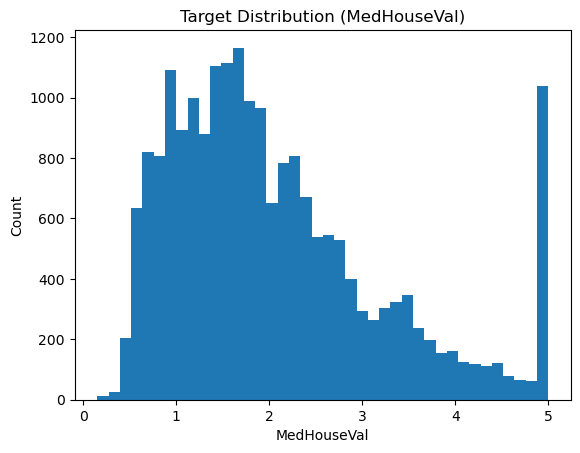

In [3]:
# Quick target distribution
plt.figure()
plt.hist(y, bins=40)
plt.xlabel("MedHouseVal")
plt.ylabel("Count")
plt.title("Target Distribution (MedHouseVal)")
plt.show()

### Interpretation

The California Housing dataset represents socio-economic and geographical
characteristics of districts in California. All input features are numerical
and describe aggregated properties of regions, such as median income, housing
age, population density, and geographic location.

From an a priori perspective, features such as **MedInc (median income)**,
**AveRooms**, and the **geographical coordinates (Latitude and Longitude)**
are expected to be highly informative for predicting house prices. Median
income directly reflects purchasing power, while location-related features
are known to be strong indicators of real estate value.

The target variable, **MedHouseVal**, exhibits a right-skewed distribution.
Most districts have house values concentrated in the lower to mid range,
while a smaller number of districts have very high values. Additionally,
a sharp peak at the upper bound (around 5.0) is visible, which is caused by
the target value being capped in the original dataset.

This skewness and the presence of a ceiling effect suggest that predictions
for high-priced districts may be more uncertain. Consequently, larger
prediction errors are expected for extreme target values compared to the
majority of the data.


---
# 2) Train/Test Split & Baseline Model Training

We train an XGBoost regressor. Keep the training fast and reproducible.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  0.3117
RMSE: 0.4679
R^2:  0.8330


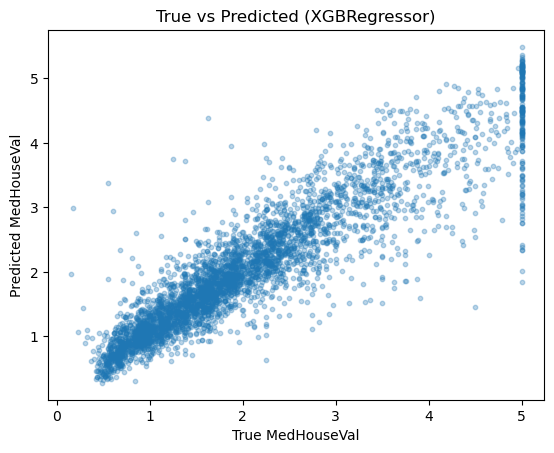

In [5]:
# True vs predicted
plt.figure()
plt.scatter(y_test, y_pred, s=10, alpha=0.3)
plt.xlabel("True MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("True vs Predicted (XGBRegressor)")
plt.show()

### Interpretation

The scatter plot compares the true target values with the predictions of the
XGBoost regressor. Overall, the model demonstrates strong predictive performance,
as indicated by an R² score of 0.833, with predictions closely following the
ideal diagonal line.

For low to medium house values, the predictions are tightly clustered around
the diagonal, suggesting high accuracy in this range. However, the dispersion
of points increases for higher target values, indicating larger prediction
errors for expensive districts.

A vertical concentration of points at the upper bound of the target value
(around 5.0) can be observed. This behavior is caused by the ceiling effect in
the dataset, where house values are capped at a maximum value. As a result,
the model has limited information to distinguish between very high-priced
districts, leading to increased uncertainty in this region.


---
# 3) XAI Method 1 — Permutation Importance (Global)

**Idea:** Shuffle one feature at a time and measure the drop in performance.  
This approximates global feature importance based on model reliance.

In [6]:
# Permutation importance on the test set
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="neg_mean_squared_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df)

,feature,importance_mean,importance_std
6,Latitude,1.969309,0.042138
7,Longitude,1.721787,0.026254
0,MedInc,0.548519,0.012762
5,AveOccup,0.180908,0.005504
2,AveRooms,0.075160,0.004894
1,HouseAge,0.049851,0.003295
3,AveBedrms,0.006921,0.001141
4,Population,0.006768,0.000893


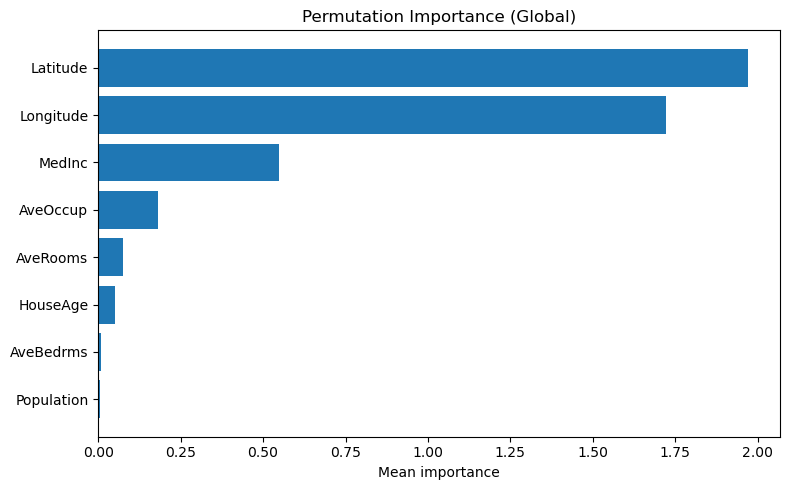

In [7]:
# Plot permutation importances
plt.figure(figsize=(8, 5))
plt.barh(
    perm_df["feature"][::-1],
    perm_df["importance_mean"][::-1]
)
plt.xlabel("Mean importance")
plt.title("Permutation Importance (Global)")
plt.tight_layout()
plt.show()

### Interpretation (Permutation Importance)

The permutation importance analysis reveals that **geographical features**
(Latitude and Longitude) are by far the most influential variables for the
XGBoost model. This indicates that location plays a dominant role in predicting
house prices, which is consistent with real-world real estate markets where
proximity to urban centers, coastal areas, and infrastructure strongly affects
property values.

The feature **MedInc (median income)** ranks third, highlighting the importance
of socio-economic conditions and purchasing power in determining housing prices.
Other features such as **AveOccup** and **AveRooms** contribute to the model
performance to a lesser extent, while **Population** and **AveBedrms** show
minimal influence when considered independently.

It is important to note that permutation importance can be affected by feature
correlations. In particular, geographical features may capture information that
overlaps with other variables, potentially amplifying their measured importance.
Therefore, these results should be interpreted in combination with other
explainability methods.


---
# 4) XAI Method 2 — SHAP (Global + Local)

**Idea:** SHAP values attribute contributions of each feature to each prediction.  
- **Global:** which features matter overall (and direction of effect)  
- **Local:** why the model predicted a specific value for one instance

In [8]:
# Build SHAP explainer 
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)

 99%|===================| 4107/4128 [01:35<00:00]        

SHAP values shape: (4128, 8)


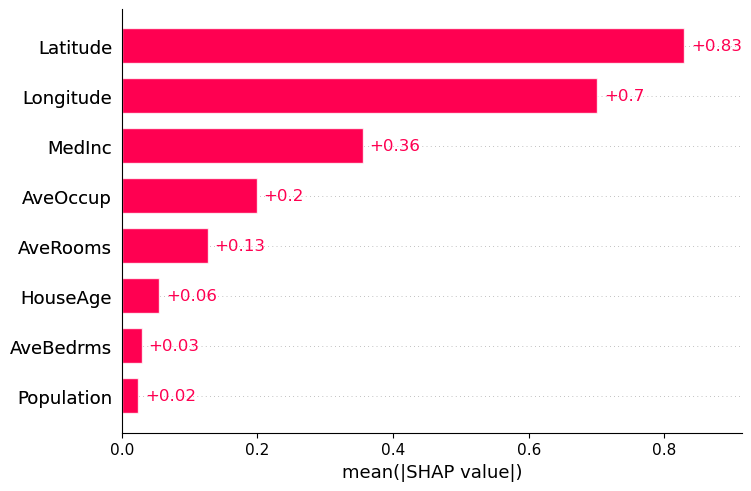

In [9]:
# Global summary plot (bar)
shap.plots.bar(shap_values, max_display=12)

C:\Users\milad\AppData\Local\Temp\ipykernel_17468\1632579210.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_test, max_display=12)


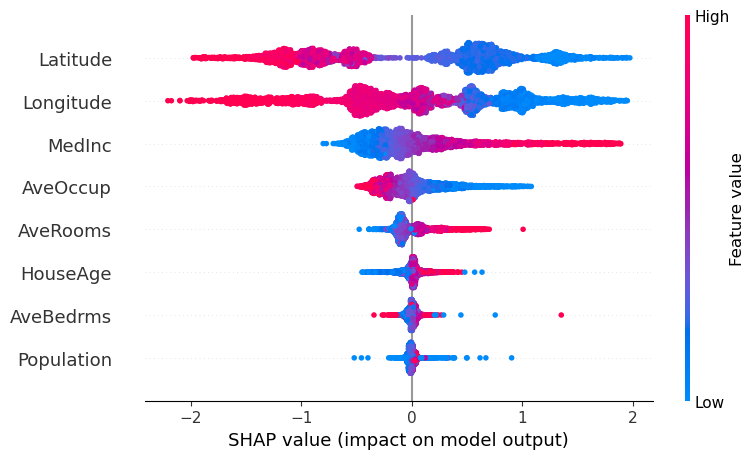

In [10]:
# Global summary plot (beeswarm)
shap.summary_plot(shap_values.values, X_test, max_display=12)

### Local explanations 
Below we pick:  
- one **low predicted** example  
- one **high predicted** example

In [11]:
# Choose indices for local explanations
idx_low = int(np.argmin(y_pred))
idx_high = int(np.argmax(y_pred))

print("Low idx:", idx_low, "Pred:", y_pred[idx_low], "True:", float(y_test.iloc[idx_low]))
print("High idx:", idx_high, "Pred:", y_pred[idx_high], "True:", float(y_test.iloc[idx_high]))

Low idx: 175 Pred: 0.27849385 True: 0.485
High idx: 348 Pred: 5.4880996 True: 5.00001


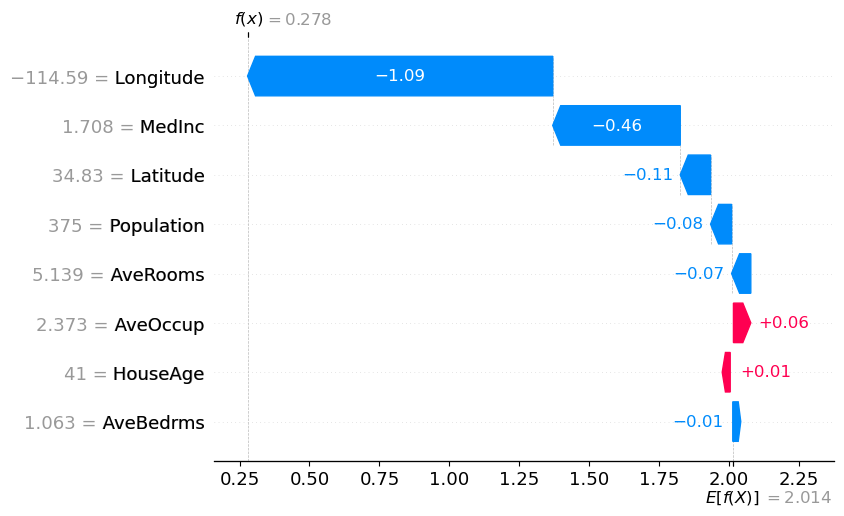

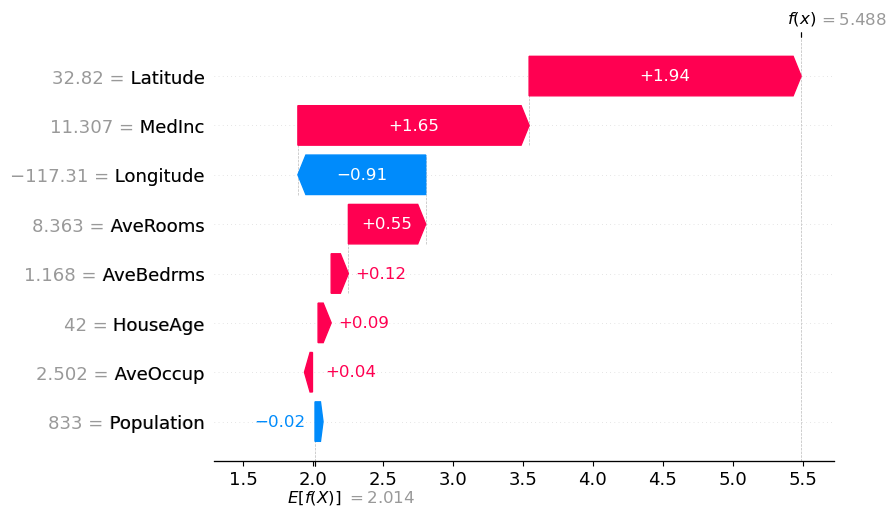

In [12]:
# Waterfall plots (local explanations)
shap.plots.waterfall(shap_values[idx_low], max_display=12)
shap.plots.waterfall(shap_values[idx_high], max_display=12)

### Interpretation (SHAP)

The global SHAP analysis confirms the findings of the permutation importance
results, identifying **Latitude**, **Longitude**, and **MedInc** as the most
influential features. This consistency across different explainability methods
strengthens confidence in the model’s learned behavior.

The SHAP beeswarm plot provides additional insight into the **directionality**
of feature effects. Higher median income values consistently contribute
positively to the predicted house value, while lower income values have a
negative impact. Similarly, geographical features exhibit structured patterns,
indicating that certain locations systematically increase or decrease predicted
prices.

Local SHAP explanations further illustrate how individual predictions are
formed. For a low-priced district, negative contributions from geographical
location and income dominate the prediction. In contrast, for a high-priced
district, strong positive contributions from latitude, median income, and
average number of rooms jointly push the prediction towards a high value.
These local explanations demonstrate that the model relies on a combination
of features rather than a single dominant factor.


---
# 5) XAI Method 3 — PDP + ICE

**Idea:**  
- **PDP (Partial Dependence Plot):** average effect of one feature on prediction.  
- **ICE (Individual Conditional Expectation):** per-instance effect (reveals heterogeneity).

We plot PDP/ICE for a few top features (based on SHAP/permutation).

In [13]:
# Pick features to analyze
top_features = perm_df["feature"].head(3).tolist()
print("Chosen features for PDP/ICE:", top_features)

Chosen features for PDP/ICE: ['Latitude', 'Longitude', 'MedInc']


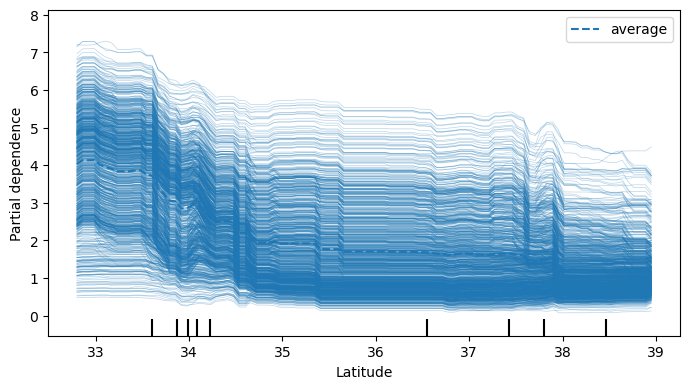

In [14]:
# PDP with ICE (kind="both")
fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(
    model, X_test, features=[top_features[0]], kind="both", ax=ax
)
plt.tight_layout()
plt.show()

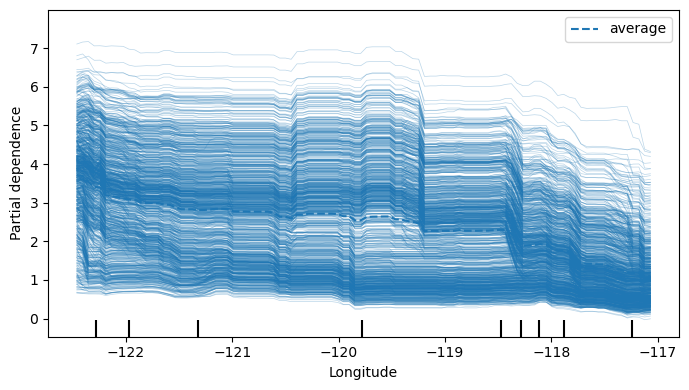

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(
    model, X_test, features=[top_features[1]], kind="both", ax=ax
)
plt.tight_layout()
plt.show()

### Interpretation (PDP + ICE)

The partial dependence plots reveal that the relationships between the selected
features and the predicted house value are strongly **non-linear**. In particular,
both **Latitude** and **Longitude** exhibit step-like patterns, indicating that
geographical effects on house prices change across regions rather than following
a smooth linear trend.

The ICE curves show substantial variability across individual instances,
demonstrating a high degree of **heterogeneity**. This suggests that the effect
of geographical location depends on interactions with other features, such as
income level or local population characteristics.

The overall trends observed in the PDPs are consistent with the SHAP results.
Features identified as important by SHAP also show strong marginal effects in
the PDPs, while the ICE plots explain why a single global effect is insufficient
to fully describe their influence. Together, these results confirm that location
features play a dominant but context-dependent role in the model’s predictions.


---
# 6) XAI Method 4 — Counterfactual Explanations (DiCE)

**Idea:** Find minimal changes to input features that would change the model output in a desired direction.

For regression, we can define a desired range (e.g., “increase predicted price above some threshold”).

In [16]:
# Prepare DiCE data + model wrapper

# DiCE expects a single DataFrame with target column
dice_df = df.copy()

# Define continuous features (all here are continuous)
continuous_features = list(X.columns)

d = dice_ml.Data(dataframe=dice_df, continuous_features=continuous_features, outcome_name="MedHouseVal")

# Model wrapper: sklearn-like regressor
m = dice_ml.Model(model=model, backend="sklearn", model_type="regressor")

exp = dice_ml.Dice(d, m, method="random")
print("DiCE ready !")

DiCE ready !


### Choose a query instance
We select a query instance from the test set (specifically a low-predicted sample) and ask:  
“What minimal changes increase predicted value into a higher range?”

In [17]:
# Query instance: use the low-predicted one
query_instance = X_test.iloc[[idx_low]].copy()
display(query_instance)

current_pred = float(model.predict(query_instance)[0])
print("Current prediction:", current_pred)

# Define a desired outcome range (edit as you like)
# Example: increase to at least current_pred + 0.5 (in dataset units)
desired_lower = current_pred + 0.5
desired_upper = desired_lower + 0.5

print("Desired prediction range:", (desired_lower, desired_upper))

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
13925,1.7083,41.0,5.139241,1.063291,375.0,2.373418,34.83,-114.59


Current prediction: 0.27849385142326355
Desired prediction range: (0.7784938514232635, 1.2784938514232635)


In [18]:
# Generate counterfactuals 
# Reduce total_CFs if needed for speed.
dice_exp = exp.generate_counterfactuals(
    query_instances=query_instance,
    total_CFs=3,
    desired_range=[desired_lower, desired_upper],
    features_to_vary="all"
)

# Show counterfactuals
dice_exp.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.64it/s]

Query instance (original outcome : 0.0)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.7083,41.0,5.139241,1.063291,375.0,2.373418,34.830002,-114.589996,0.0



Diverse Counterfactual set (new outcome: [0.7784938514232635, 1.2784938514232635])


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.7083,41.0,91.900000,1.063291,375.0,410.800000,34.83,-114.59,0.922718
1,1.7083,41.0,5.139241,26.300000,375.0,2.373418,34.57,-114.59,1.157111
2,1.7083,41.0,5.139241,29.000000,375.0,2.373418,34.83,-114.59,1.147360


### Interpretation (Counterfactual Explanations)

The counterfactual analysis identifies minimal changes to the input features
that would increase the predicted house value from a very low baseline into
the desired target range. The generated counterfactuals suggest that the model
is highly sensitive to geographical location, as small changes in longitude
alone can significantly increase the predicted value.

In addition, some counterfactuals propose substantial changes to housing-related
features such as the average number of rooms or bedrooms. While these changes
are not always realistic from a real-world perspective, they reveal which
features the model considers most influential for increasing house prices.

Overall, the counterfactual explanations complement the previous explainability
methods by providing actionable insights into the model’s decision logic, while
also highlighting limitations related to feasibility and realism.

These results also highlight a limitation of unconstrained counterfactual
generation, as some suggested changes are not practically feasible, motivating
the need for domain constraints in real-world applications.

Note that the reported original outcome is shown in the normalized outcome
space used internally by DiCE and does not correspond directly to the raw
model prediction.

---
# 7) Combined Summary 



### Final Combined Summary

**Global importance:**  
Both global explainability methods, Permutation Feature Importance and SHAP,
consistently identify geographical features (Latitude and Longitude) as the most
influential variables for the model’s predictions, followed by median income
(MedInc). This strong agreement between two fundamentally different methods
reinforces the conclusion that location and socio-economic factors dominate
house price prediction in the dataset.

**Directionality (SHAP) and marginal effects (PDP):**  
SHAP analysis reveals the direction of feature effects, showing that higher
median income values systematically increase predicted house prices, while
geographical features exhibit structured positive and negative effects depending
on location. PDP and ICE plots further demonstrate that these relationships are
highly non-linear and region-dependent. The substantial spread of ICE curves
indicates strong heterogeneity, meaning that the impact of location varies
significantly across different districts.

**Local explanations:**  
Local SHAP explanations show that individual predictions are driven by a
combination of features rather than a single dominant factor. Low-priced
predictions are primarily caused by unfavorable geographic location and low
income levels, whereas high-priced predictions result from the joint positive
contributions of location, income, and housing-related characteristics.

**Actionability (counterfactuals):**  
Counterfactual explanations generated with DiCE provide actionable insights by
highlighting minimal feature changes required to increase predicted house values.
The results show that the model is particularly sensitive to changes in
geographical location and housing-related features. While some suggested changes
are not fully realistic, they reveal which factors the model considers most
effective for altering its predictions.

**Limitations & future work:**  
Several limitations should be considered when interpreting these results.
Geographical features are highly correlated with other variables, which may
inflate their apparent importance. Additionally, the dataset exhibits a ceiling
effect in the target variable, limiting the model’s ability to distinguish
between very high-priced districts. Future work could incorporate domain
constraints for counterfactual generation and explore more realistic,
policy-aware explanations.


---
# 8) References

- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model
  Predictions*. Advances in Neural Information Processing Systems (NeurIPS).
  https://arxiv.org/abs/1705.07874

- Mothilal, R. K., Sharma, A., & Tan, C. (2020). *Explaining Machine Learning
  Classifiers through Diverse Counterfactual Explanations*. FAT*.
  https://arxiv.org/abs/1905.07697

- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD.
  https://arxiv.org/abs/1603.02754

- California Housing Dataset. scikit-learn documentation:
  https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
